[(33, 0.5151515151515151), (0, 0.48484848484848486), (32, 0.36363636363636365), (2, 0.30303030303030304), (1, 0.2727272727272727)]
[('Grin', 0.19672131147540983), ('SN4', 0.18032786885245902), ('Topless', 0.18032786885245902), ('Scabs', 0.16393442622950818), ('Trigger', 0.16393442622950818)]


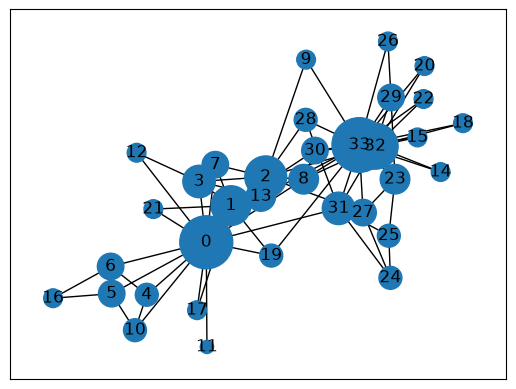

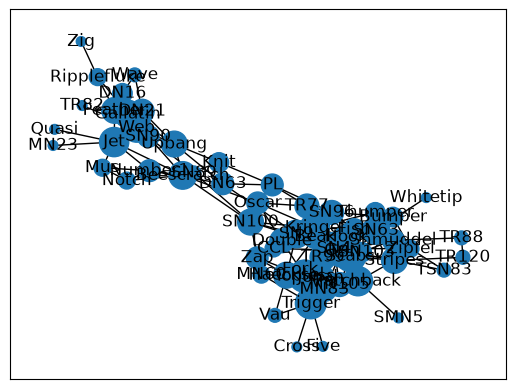

<Figure size 2000x2000 with 0 Axes>

In [2]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
def calculateDegreeCentrality(G):
    N = G.number_of_nodes()
    degrees = {}
    centrality = {}
    for n in G.nodes():
        k = len(list(G.neighbors(n)))
        c = k/(N-1)
        degrees[n] = k
        centrality[n] = c
    
    return degrees, centrality


G_karate = nx.karate_club_graph()
G_dolphins = nx.read_gml('dolphins.gml')

degrees_karate, centrality_karate = calculateDegreeCentrality(G_karate)
degrees_dolphins, centrality_dolphins = calculateDegreeCentrality(G_dolphins)

def getcentrality(item):
    return item[1]
top5_karate = sorted(centrality_karate.items(), key=getcentrality, reverse=True)[:5]
top5_dolphins = sorted(centrality_dolphins.items(), key = getcentrality, reverse=True)[:5]
size_of_nodes = []
for node in range(34):
    size_of_nodes.append(centrality_karate[node]*3000)
    
size_of_dolphins = []
for node in centrality_dolphins.keys():
    size_of_dolphins.append(centrality_dolphins[node]*3000)
    

print(top5_karate)
print(top5_dolphins)
nx.draw_networkx(G_karate, node_size = size_of_nodes, with_labels=True)
plt.show()

nx.draw_networkx(G_dolphins, node_size=size_of_dolphins, with_labels=True)
plt.figure(figsize=(20,20))
plt.show()
    
    



=============== Karate Club ===============

--- Manual Closeness Centrality (Top 5) ---
1. Node 0: 0.5690
2. Node 2: 0.5593
3. Node 33: 0.5500
4. Node 31: 0.5410
5. Node 8: 0.5156

--- NetworkX Verification (Top 5) ---
1. Node 0: 0.5690
2. Node 2: 0.5593
3. Node 33: 0.5500
4. Node 31: 0.5410
5. Node 8: 0.5156

Verification Match: True

Most Central Node (Closeness): 0
Most Central Node (Degree)   : 33
Verdict: Different individuals lead closeness vs degree centrality.

=============== Dolphin Social Network ===============

--- Manual Closeness Centrality (Top 5) ---
1. Node SN100: 0.4178
2. Node SN9: 0.4040
3. Node SN4: 0.3987
4. Node Kringel: 0.3910
5. Node Grin: 0.3765

--- NetworkX Verification (Top 5) ---
1. Node SN100: 0.4178
2. Node SN9: 0.4040
3. Node SN4: 0.3987
4. Node Kringel: 0.3910
5. Node Grin: 0.3765

Verification Match: True

Most Central Node (Closeness): SN100
Most Central Node (Degree)   : Grin
Verdict: Different individuals lead closeness vs degree centrality.


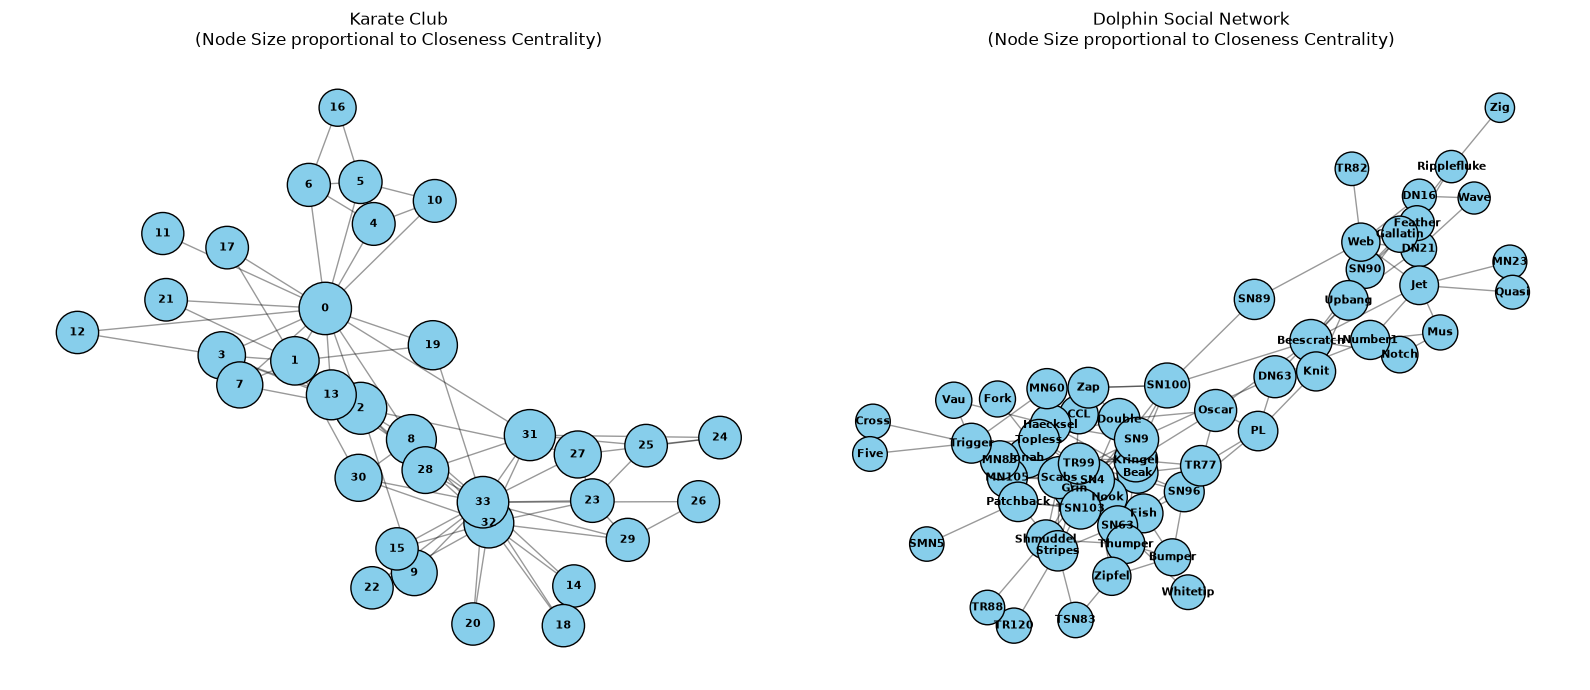

In [3]:
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx



def manual_bfs_shortest_paths(graph, start_node):
    distances = {node: -1 for node in graph.nodes()}
    distances[start_node] = 0

    queue = deque([start_node])

    while queue:
        current = queue.popleft()
        for neighbor in graph.neighbors(current):
            if distances[neighbor] == -1:
                distances[neighbor] = distances[current] + 1
                queue.append(neighbor)

    return distances


def compute_closeness_centrality(graph):
    
    N = graph.number_of_nodes()
    closeness_dict = {}

    for node in graph.nodes():
        distances = manual_bfs_shortest_paths(graph, node)
    
        total_distance = sum(distances.values())

        if total_distance > 0:
            closeness_dict[node] = (N - 1) / total_distance
        else:
            closeness_dict[node] = 0.0

    return closeness_dict


karate = nx.karate_club_graph()
dolphins = nx.dolphins_social_network() if hasattr(
    nx, "dolphins_social_network"
) else nx.read_gml("dolphins.gml")

networks = {"Karate Club": karate, "Dolphin Social Network": dolphins}


manual_closeness_results = {}

for name, G in networks.items():
    print(f"\n{'='*15} {name} {'='*15}")

    
    manual_cc = compute_closeness_centrality(G)
    manual_closeness_results[name] = manual_cc


    top_5_manual = sorted(
        manual_cc.items(), key=lambda item: item[1], reverse=True
    )[:5]

    print("\n--- Manual Closeness Centrality (Top 5) ---")
    for rank, (node, val) in enumerate(top_5_manual, 1):
        print(f"{rank}. Node {node}: {val:.4f}")

    
    nx_cc = nx.closeness_centrality(G)
    top_5_nx = sorted(nx_cc.items(), key=lambda item: item[1], reverse=True)[:5]

    print("\n--- NetworkX Verification (Top 5) ---")
    for rank, (node, val) in enumerate(top_5_nx, 1):
        print(f"{rank}. Node {node}: {val:.4f}")


    is_correct = all(
        abs(manual_cc[node] - nx_cc[node]) < 1e-6 for node in G.nodes()
    )
    print(f"\nVerification Match: {is_correct}")

    deg_centrality = nx.degree_centrality(G)
    top_closeness_node = top_5_manual[0][0]
    top_degree_node = max(
        deg_centrality.items(), key=lambda item: item[1]
    )[0]

    print(f"\nMost Central Node (Closeness): {top_closeness_node}")
    print(f"Most Central Node (Degree)   : {top_degree_node}")
    if top_closeness_node == top_degree_node:
        print("Verdict: The same individual is top-ranked in both metrics.")
    else:
        print(
            "Verdict: Different individuals lead closeness vs degree centrality."
        )


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (name, G) in zip(axes, networks.items()):
    cc_values = manual_closeness_results[name]


    node_sizes = [cc_values[node] * 2500 for node in G.nodes()]

    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=node_sizes,
        node_color="skyblue",
        edgecolors="black",
        ax=ax,
    )
    nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

    ax.set_title(f"{name}\n(Node Size proportional to Closeness Centrality)")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def manual_bfs_distances(graph, start_node):
    """Computes outward shortest path lengths from start_node to all reachable nodes using BFS."""
    distances = {node: -1 for node in graph.nodes()}
    distances[start_node] = 0

    queue = deque([start_node])

    while queue:
        curr = queue.popleft()
        for neighbor in graph.successors(curr):  # Directed outgoing edges
            if distances[neighbor] == -1:
                distances[neighbor] = distances[curr] + 1
                queue.append(neighbor)

    # Return only reachable node distances (excluding distance=0 to self)
    return {k: v for k, v in distances.items() if v > 0}


def manual_closeness_centrality(graph):
    """Calculates outward closeness centrality from scratch using BFS.

    C_C(u) = (|R(u)| - 1) / (N - 1) * (|R(u)| - 1) / sum(d(u, v))
    (with Wasserman-Faust scaling for reachability components)
    """
    N = graph.number_of_nodes()
    closeness_dict = {}

    for u in graph.nodes():
        reachable_dists = manual_bfs_distances(graph, u)
        num_reachable = len(reachable_dists)  # Number of nodes reachable from u

        if num_reachable == 0 or N <= 1:
            closeness_dict[u] = 0.0
        else:
            sum_dist = sum(reachable_dists.values())
            # Component fraction * reciprocal of average distance
            reach_ratio = num_reachable / (N - 1)
            avg_dist_reciprocal = num_reachable / sum_dist
            closeness_dict[u] = reach_ratio * avg_dist_reciprocal

    return closeness_dict

In [8]:
file = open('reachability.txt', 'r')
lines = file.readlines()
edges = []
for line in lines:
    line.strip()
    e = line.split(' ')
    edges.append((e[0], e[1]))

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
G = nx.DiGraph()
G.add_edges_from(edges)

out_degree = {}
in_degree = {}
out_degree_centrality = {}
in_degree_centrality = {}
N = G.number_of_nodes()
for node in G.nodes():
    in_degree[node] = G.in_degree(node)
    out_degree[node] = G.out_degree(node)
    out_degree_centrality[node] = out_degree[node]/(N-1)
    in_degree_centrality[node] = in_degree[node]/(N-1)


closeness_centrality = manual_closeness_centrality(G)
def getcentrality(item):
    return item[1]
top10_out_degree_centrality = sorted(out_degree_centrality.items(), key=getcentrality, reverse=True)[:10]
top10_in_degree_centrality = sorted(in_degree_centrality.items(), key=getcentrality, reverse=True)[:10]
top10_close_degree_centrality = sorted(closeness_centrality.items(), key=getcentrality, reverse=True)[:10]

print(top10_out_degree_centrality)
print(top10_in_degree_centrality)
print(top10_close_degree_centrality)

















# nx.draw_networkx(G, with_labels=True)
# plt.show()


[('246', 0.9736263736263736), ('230', 0.9494505494505494), ('74', 0.945054945054945), ('368', 0.945054945054945), ('100', 0.9428571428571428), ('294', 0.9406593406593406), ('94', 0.9384615384615385), ('434', 0.9384615384615385), ('324', 0.9318681318681319), ('416', 0.8989010989010989)]
[('246', 0.9736263736263736), ('368', 0.9692307692307692), ('94', 0.9494505494505494), ('74', 0.9428571428571428), ('230', 0.9428571428571428), ('294', 0.9406593406593406), ('100', 0.9384615384615385), ('434', 0.9340659340659341), ('324', 0.9296703296703297), ('383', 0.9186813186813186)]
[('246', 0.974304068522484), ('230', 0.9518828451882845), ('74', 0.9479166666666666), ('368', 0.9479166666666666), ('100', 0.9459459459459459), ('294', 0.9439834024896265), ('94', 0.9420289855072463), ('434', 0.9420289855072463), ('324', 0.9362139917695473), ('416', 0.908183632734531)]
